In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
da = '/Users/siddharthagrawal/Desktop/solar_forecast_platform/data/processed/jaipur_features_90d.parquet'
df = pd.read_parquet(da)

print("Total rows;", len(df))
print("Data Range:", df.index.min , 'to' , df.index.max)

Total rows; 1992
Data Range: <bound method Index.min of DatetimeIndex(['2024-01-08 00:00:00+05:30', '2024-01-08 01:00:00+05:30',
               '2024-01-08 02:00:00+05:30', '2024-01-08 03:00:00+05:30',
               '2024-01-08 04:00:00+05:30', '2024-01-08 05:00:00+05:30',
               '2024-01-08 06:00:00+05:30', '2024-01-08 07:00:00+05:30',
               '2024-01-08 08:00:00+05:30', '2024-01-08 09:00:00+05:30',
               ...
               '2024-03-30 14:00:00+05:30', '2024-03-30 15:00:00+05:30',
               '2024-03-30 16:00:00+05:30', '2024-03-30 17:00:00+05:30',
               '2024-03-30 18:00:00+05:30', '2024-03-30 19:00:00+05:30',
               '2024-03-30 20:00:00+05:30', '2024-03-30 21:00:00+05:30',
               '2024-03-30 22:00:00+05:30', '2024-03-30 23:00:00+05:30'],
              dtype='datetime64[us, Asia/Kolkata]', length=1992, freq=None)> to <bound method Index.max of DatetimeIndex(['2024-01-08 00:00:00+05:30', '2024-01-08 01:00:00+05:30',
              

In [5]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

print(f"Train: {len(train)} rows | {train.index.min().date()} to {train.index.max().date()}")
print(f"Val:   {len(val)} rows | {val.index.min().date()} to {val.index.max().date()}")
print(f"Test:  {len(test)} rows | {test.index.min().date()} to {test.index.max().date()}")

Train: 1394 rows | 2024-01-08 to 2024-03-06
Val:   299 rows | 2024-03-06 to 2024-03-18
Test:  299 rows | 2024-03-18 to 2024-03-30


In [6]:
df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'precipitation',
       'cloud_cover', 'wind_speed_10m', 'shortwave_radiation',
       'direct_radiation', 'diffuse_radiation', 'solar_output_mw',
       'clear_sky_ghi', 'hour', 'day_of_week', 'month', 'is_daytime',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'solar_lag_1h',
       'solar_lag_24h', 'solar_lag_48h', 'solar_lag_168h',
       'solar_rolling_mean_3h', 'solar_rolling_mean_6h',
       'solar_rolling_std_3h', 'clear_sky_output', 'clear_sky_ratio'],
      dtype='str')

In [8]:
feature_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
       'cloud_cover', 'wind_speed_10m', 'shortwave_radiation',
       'direct_radiation', 'diffuse_radiation',
       'clear_sky_ghi', 'hour', 'day_of_week', 'month', 'is_daytime',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'solar_lag_1h',
       'solar_lag_24h', 'solar_lag_48h', 'solar_lag_168h',
       'solar_rolling_mean_3h', 'solar_rolling_mean_6h',
       'solar_rolling_std_3h', 'clear_sky_ratio']

target_col = 'solar_output_mw'


X_train = train[feature_cols]
y_train = train[target_col]

X_val = val[feature_cols]
y_val = val[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("\nX_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

assert 'solar_output_mw' not in feature_cols
assert 'clear_sky_output' not in feature_cols
print("Clean feature list — no leakage")
print("Features:", len(feature_cols))


X_train shape: (1394, 25)
X_val shape:   (299, 25)
X_test shape:  (299, 25)
Clean feature list — no leakage
Features: 25


XGBoost Modelling starts:

In [10]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error


model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print("Training complete")

[0]	validation_0-rmse:22.39016
[100]	validation_0-rmse:0.57311
[200]	validation_0-rmse:0.47943
[300]	validation_0-rmse:0.47812
[400]	validation_0-rmse:0.47838
[499]	validation_0-rmse:0.47822
Training complete


In [11]:
from sklearn.metrics import mean_squared_error

y_pred_val = model_xgb.predict(X_val)

mae  = mean_absolute_error(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))

daytime_mask = y_val > 1.0  

mape = np.mean(
    np.abs((y_val[daytime_mask] - y_pred_val[daytime_mask]) / 
            y_val[daytime_mask])
) * 100 

print(f"MAE:        {mae:.2f} MW")
print(f"RMSE:       {rmse:.2f} MW")  
print(f"MAPE:       {mape:.2f}%  (daytime only)")


MAE:        0.25 MW
RMSE:       0.48 MW
MAPE:       2.17%  (daytime only)


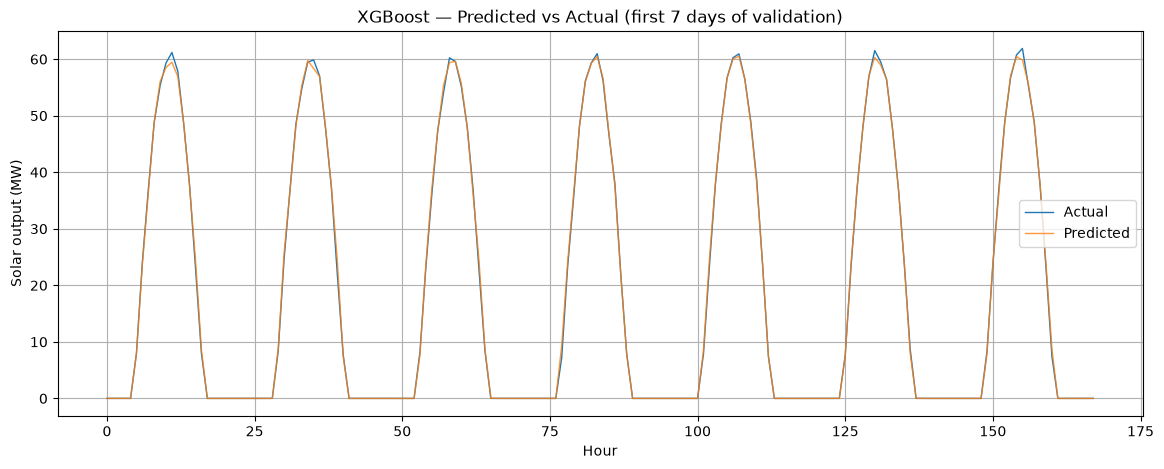

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(y_val.values[:168], label='Actual', linewidth=1)
plt.plot(y_pred_val[:168], label='Predicted', linewidth=1, alpha=0.8)
plt.title('XGBoost — Predicted vs Actual (first 7 days of validation)')
plt.xlabel('Hour')
plt.ylabel('Solar output (MW)')
plt.legend()
plt.grid(True)
plt.show()

                  feature    importance
8           clear_sky_ghi  7.398502e-01
19          solar_lag_48h  1.426172e-01
5     shortwave_radiation  7.898026e-02
6        direct_radiation  2.742535e-02
14               hour_cos  5.663404e-03
20         solar_lag_168h  4.299495e-03
7       diffuse_radiation  7.156495e-04
18          solar_lag_24h  2.162319e-04
24        clear_sky_ratio  1.438410e-04
15              month_sin  2.221275e-05
11                  month  1.664992e-05
16              month_cos  1.610483e-05
21  solar_rolling_mean_3h  8.625371e-06
23   solar_rolling_std_3h  4.073446e-06
0          temperature_2m  2.945520e-06
22  solar_rolling_mean_6h  2.914671e-06
9                    hour  2.874259e-06
17           solar_lag_1h  2.601029e-06
3             cloud_cover  2.556856e-06
10            day_of_week  2.330534e-06
4          wind_speed_10m  2.120777e-06
1    relative_humidity_2m  1.449123e-06
13               hour_sin  8.637106e-07
2           precipitation  0.000000e+00


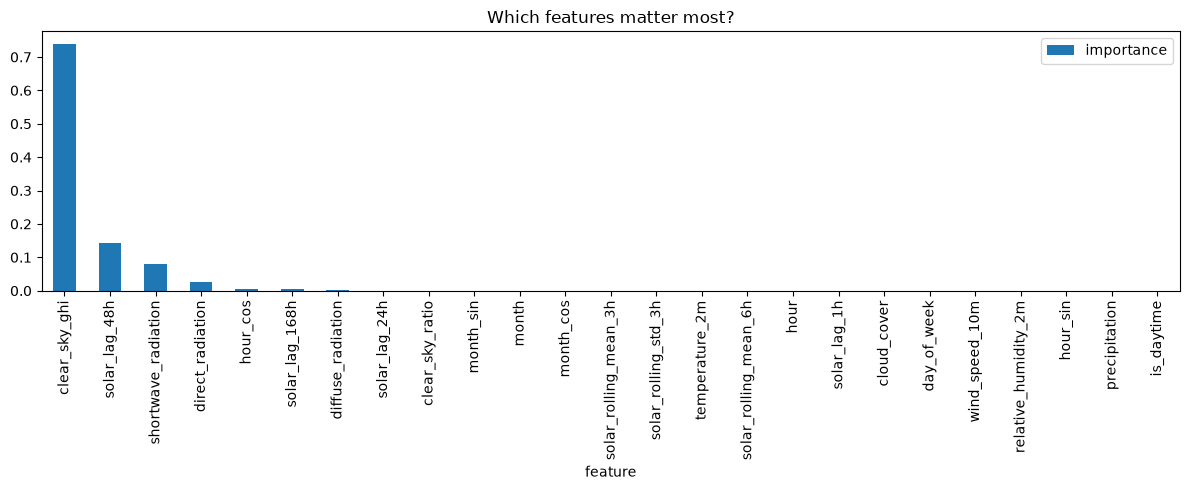

In [13]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

# Plot it
importance.plot(kind='bar', x='feature', y='importance',
                title='Which features matter most?',
                figsize=(12, 5))
plt.tight_layout()
plt.show()

In [14]:
import pickle
import os

# Create the folder if it doesn't exist
os.makedirs('src/models', exist_ok=True)

# Save model
with open('src/models/xgboost_solar_v1.pkl', 'wb') as f:
    pickle.dump(model_xgb, f)

print("Saved to:", os.path.abspath('src/models/xgboost_solar_v1.pkl'))

Saved to: /Users/siddharthagrawal/Desktop/solar_forecast_platform/notebooks/src/models/xgboost_solar_v1.pkl
